# Исследование объявлений о продаже квартир

В вашем распоряжении данные сервиса Яндекс.Недвижимость — архив объявлений о продаже квартир в Санкт-Петербурге и соседних населённых пунктов за несколько лет. Нужно научиться определять рыночную стоимость объектов недвижимости. Ваша задача — установить параметры. Это позволит построить автоматизированную систему: она отследит аномалии и мошенническую деятельность. 

По каждой квартире на продажу доступны два вида данных. Первые вписаны пользователем, вторые — получены автоматически на основе картографических данных. Например, расстояние до центра, аэропорта, ближайшего парка и водоёма. 

### Откройте файл с данными и изучите общую информацию. 

#### Импорт библиотек.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import re
import datetime as dt
import numpy as np

#### Чтение и демонстрация содержимого файла.

In [2]:
df = pd.read_csv('/datasets/real_estate_data.csv', sep='\t')
display(df.head(20))

,total_images,last_price,total_area,first_day_exposition,rooms,ceiling_height,floors_total,living_area,floor,is_apartment,...,kitchen_area,balcony,locality_name,airports_nearest,cityCenters_nearest,parks_around3000,parks_nearest,ponds_around3000,ponds_nearest,days_exposition
0,20,13000000.0,108.00,2019-03-07T00:00:00,3,2.70,16.0,51.00,8,NaN,...,25.00,NaN,Санкт-Петербург,18863.0,16028.0,1.0,482.0,2.0,755.0,NaN
1,7,3350000.0,40.40,2018-12-04T00:00:00,1,NaN,11.0,18.60,1,NaN,...,11.00,2.0,посёлок Шушары,12817.0,18603.0,0.0,NaN,0.0,NaN,81.0
2,10,5196000.0,56.00,2015-08-20T00:00:00,2,NaN,5.0,34.30,4,NaN,...,8.30,0.0,Санкт-Петербург,21741.0,13933.0,1.0,90.0,2.0,574.0,558.0
3,0,64900000.0,159.00,2015-07-24T00:00:00,3,NaN,14.0,NaN,9,NaN,...,NaN,0.0,Санкт-Петербург,28098.0,6800.0,2.0,84.0,3.0,234.0,424.0
4,2,10000000.0,100.00,2018-06-19T00:00:00,2,3.03,14.0,32.00,13,NaN,...,41.00,NaN,Санкт-Петербург,31856.0,8098.0,2.0,112.0,1.0,48.0,121.0
5,10,2890000.0,30.40,2018-09-10T00:00:00,1,NaN,12.0,14.40,5,NaN,...,9.10,NaN,городской посёлок Янино-1,NaN,NaN,NaN,NaN,NaN,NaN,55.0
6,6,3700000.0,37.30,2017-11-02T00:00:00,1,NaN,26.0,10.60,6,NaN,...,14.40,1.0,посёлок Парголово,52996.0,19143.0,0.0,NaN,0.0,NaN,155.0
7,5,7915000.0,71.60,2019-04-18T00:00:00,2,NaN,24.0,NaN,22,NaN,...,18.90,2.0,Санкт-Петербург,23982.0,11634.0,0.0,NaN,0.0,NaN,NaN
8,20,2900000.0,33.16,2018-05-23T00:00:00,1,NaN,27.0,15.43,26,NaN,...,8.81,NaN,посёлок Мурино,NaN,NaN,NaN,NaN,NaN,NaN,189.0
9,18,5400000.0,61.00,2017-02-26T00:00:00,3,2.50,9.0,43.60,7,NaN,...,6.50,2.0,Санкт-Петербург,50898.0,15008.0,0.0,NaN,0.0,NaN,289.0


#### Изучение файла.

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 23699 entries, 0 to 23698
Data columns (total 22 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   total_images          23699 non-null  int64  
 1   last_price            23699 non-null  float64
 2   total_area            23699 non-null  float64
 3   first_day_exposition  23699 non-null  object 
 4   rooms                 23699 non-null  int64  
 5   ceiling_height        14504 non-null  float64
 6   floors_total          23613 non-null  float64
 7   living_area           21796 non-null  float64
 8   floor                 23699 non-null  int64  
 9   is_apartment          2775 non-null   object 
 10  studio                23699 non-null  bool   
 11  open_plan             23699 non-null  bool   
 12  kitchen_area          21421 non-null  float64
 13  balcony               12180 non-null  float64
 14  locality_name         23650 non-null  object 
 15  airports_nearest   

array([[<AxesSubplot:title={'center':'total_images'}>,
        <AxesSubplot:title={'center':'last_price'}>,
        <AxesSubplot:title={'center':'total_area'}>,
        <AxesSubplot:title={'center':'rooms'}>],
       [<AxesSubplot:title={'center':'ceiling_height'}>,
        <AxesSubplot:title={'center':'floors_total'}>,
        <AxesSubplot:title={'center':'living_area'}>,
        <AxesSubplot:title={'center':'floor'}>],
       [<AxesSubplot:title={'center':'kitchen_area'}>,
        <AxesSubplot:title={'center':'balcony'}>,
        <AxesSubplot:title={'center':'airports_nearest'}>,
        <AxesSubplot:title={'center':'cityCenters_nearest'}>],
       [<AxesSubplot:title={'center':'parks_around3000'}>,
        <AxesSubplot:title={'center':'parks_nearest'}>,
        <AxesSubplot:title={'center':'ponds_around3000'}>,
        <AxesSubplot:title={'center':'ponds_nearest'}>],
       [<AxesSubplot:title={'center':'days_exposition'}>, <AxesSubplot:>,
        <AxesSubplot:>, <AxesSubplot:>]], d

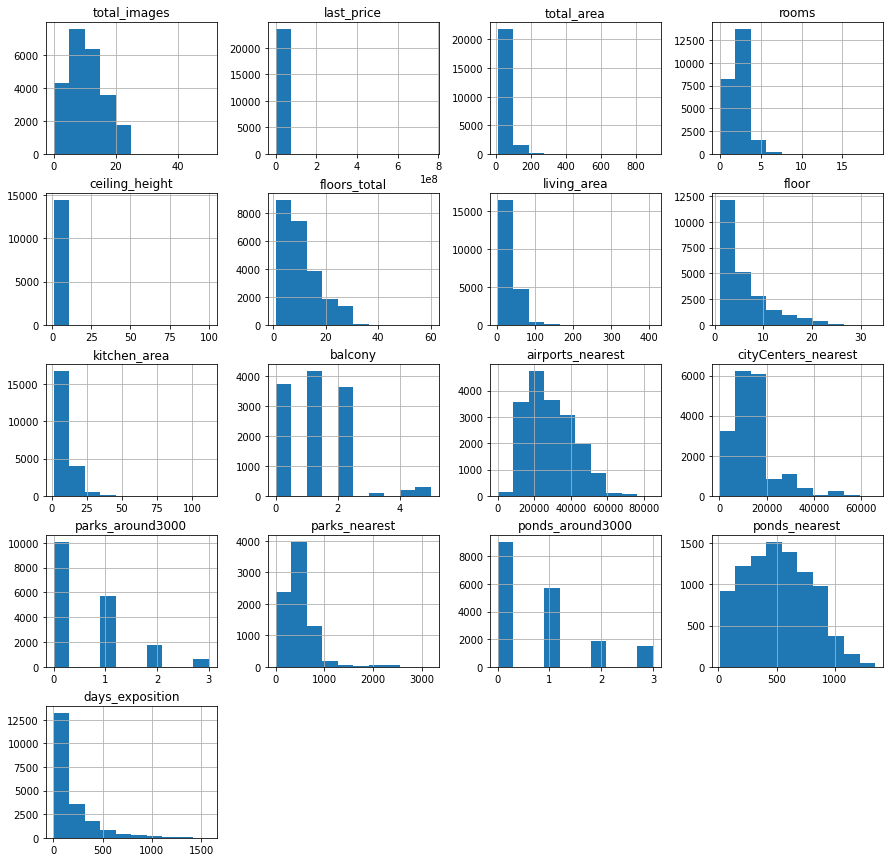

In [4]:
df.hist(figsize=(15, 15))

**Промежуточный вывод:**  

Переменные где нужно изменить тип: first_day_exposition (в дату), floors_total (в целое число), is_apartment (в булево), balcony (в целое число), parks_around3000 (в целое число), ponds_around3000 (в целое число), days_exposition (в целое число).

На гистограммах странно выглядят ceiling_height и last_price, так как практически все значения около нуля. Необычно выглядят ещё balcony, parks_around3000, ponds_around3000, но это потому что там только целые числа. Можно выделить, что в большинстве параметров Пуассоновское распределение.

Также можно отметить множество пустых значений, с которыми стоит разобраться.

### Предобработка данных

#### Выведем количество пропущенных.

In [5]:
display(df.isna().sum())

total_images                0
last_price                  0
total_area                  0
first_day_exposition        0
rooms                       0
ceiling_height           9195
floors_total               86
living_area              1903
floor                       0
is_apartment            20924
studio                      0
open_plan                   0
kitchen_area             2278
balcony                 11519
locality_name              49
airports_nearest         5542
cityCenters_nearest      5519
parks_around3000         5518
parks_nearest           15620
ponds_around3000         5518
ponds_nearest           14589
days_exposition          3181
dtype: int64

*Наблюдение:* Пропущенные значения присутствуют в ceiling_height, floors_total, living_area, is_apartment, kitchen_area, balcony, locality_name, airports_nearest, cityCenters_nearest, parks_around3000, parks_nearest, ponds_around3000, ponds_nearest, days_exposition.

#### Устрание пропусков, где возможно.

In [6]:
df['balcony'] = df['balcony'].fillna(0)

In [7]:
for t in df['rooms'].unique():
    df.loc[(df['rooms'] == t) & (df['living_area'].isna()), 'living_area'] = \
    df.loc[(df['rooms'] == t), 'living_area'].median()

In [8]:
df[df['is_apartment'] == True]

,total_images,last_price,total_area,first_day_exposition,rooms,ceiling_height,floors_total,living_area,floor,is_apartment,...,kitchen_area,balcony,locality_name,airports_nearest,cityCenters_nearest,parks_around3000,parks_nearest,ponds_around3000,ponds_nearest,days_exposition
543,11,12790000.0,56.60,2018-11-06T00:00:00,2,3.50,3.0,29.400000,1,True,...,NaN,0.0,Петергоф,35248.0,30437.0,3.0,53.0,3.0,22.0,NaN
916,11,8183000.0,70.00,2018-01-11T00:00:00,2,3.12,3.0,40.000000,3,True,...,NaN,2.0,Санкт-Петербург,45796.0,21729.0,0.0,NaN,1.0,754.0,179.0
1109,1,34878556.0,95.80,2014-12-09T00:00:00,2,NaN,6.0,58.300000,5,True,...,20.00,1.0,Санкт-Петербург,21860.0,318.0,2.0,160.0,3.0,569.0,1572.0
1608,12,2150000.0,20.10,2019-01-30T00:00:00,1,NaN,9.0,17.600000,1,True,...,NaN,0.0,Санкт-Петербург,26646.0,12147.0,0.0,NaN,0.0,NaN,13.0
2759,11,7500000.0,152.00,2018-07-27T00:00:00,3,3.00,3.0,45.000000,1,True,...,NaN,1.0,Всеволожск,NaN,NaN,NaN,NaN,NaN,NaN,7.0
2975,9,4931398.0,42.90,2018-07-23T00:00:00,1,3.15,4.0,20.390000,3,True,...,10.29,0.0,Санкт-Петербург,44870.0,20802.0,0.0,NaN,1.0,792.0,273.0
3067,13,6600000.0,95.00,2018-09-08T00:00:00,2,4.50,7.0,45.000000,7,True,...,25.00,2.0,Выборг,NaN,NaN,NaN,NaN,NaN,NaN,96.0
3816,4,4779000.0,53.10,2016-05-16T00:00:00,1,NaN,13.0,19.800000,6,True,...,15.90,2.0,Санкт-Петербург,19396.0,4516.0,0.0,NaN,1.0,826.0,60.0
3951,10,4300000.0,50.00,2019-04-20T00:00:00,1,3.00,11.0,17.000000,9,True,...,12.00,2.0,Санкт-Петербург,10143.0,11367.0,0.0,NaN,0.0,NaN,NaN
4339,19,6900000.0,72.00,2019-03-25T00:00:00,3,3.50,4.0,70.000000,1,True,...,NaN,0.0,Санкт-Петербург,31487.0,4466.0,2.0,353.0,1.0,439.0,22.0


In [9]:
df['is_apartment'] = df['is_apartment'].fillna(False)

In [10]:
df['parks_around3000'] = df.apply(lambda row: 0 if pd.isna(row['parks_nearest']) else row['parks_around3000'], axis=1)
df['ponds_around3000'] = df.apply(lambda row: 0 if pd.isna(row['ponds_nearest']) else row['ponds_around3000'], axis=1)

In [11]:
display(df.isna().sum())

total_images                0
last_price                  0
total_area                  0
first_day_exposition        0
rooms                       0
ceiling_height           9195
floors_total               86
living_area                 0
floor                       0
is_apartment                0
studio                      0
open_plan                   0
kitchen_area             2278
balcony                     0
locality_name              49
airports_nearest         5542
cityCenters_nearest      5519
parks_around3000            0
parks_nearest           15620
ponds_around3000            0
ponds_nearest           14589
days_exposition          3181
dtype: int64

***Наблюдение:***  

**ceiling_height** заполнить не получится, так как нет очевидной логической замены для высоты потолков.  
**floors_total** также заполнить нельзя, так как нет очевидной логической замены для высоты здания, однако этаж недвижимости указан и можно сказать, что здание точно имеет это количество этажей.    
**living_area** можно заменить на медианное значение в зависимости от количества комнат в квартире.  
**is_apartment** заменим пропуски на фолс, так как скорее всего там где не аппартаменты просто ничего не указывали.  
**kitchen_area** заполнить не получится, так как нет очевидной логической замены для площади кухни. Отсутствие данных о площади кухни может указывать на особенности планировки (например, кухня совмещена с гостиной).  
**locality_name** заполнить не получится, так как нет очевидной логической замены, однако можно судить, что объект точно находится в пределах Ленинградской области.  
**airports_nearest** и **cityCenters_nearest** Оставим пропуски. Отсутствие данных о расстояниях может означать, что объект недвижимости расположен в труднодоступной местности или что информация не была предоставлена продавцом.  
**parks_around3000** и **ponds_around3000** можно заменить на ноль если пропуск значения в **parks_nearest** и **ponds_nearest**.  
**days_exposition** заменить нечем, скорее всего они появились, потому что эти объявления до сих пор висят.  

***Возможные причины пропусков:***  

**Нежелание продавца предоставлять информацию:** Продавец может не указывать некоторые характеристики объекта недвижимости, например, высоту потолков, площадь кухни, наличие балкона, чтобы скрыть недостатки или увеличить привлекательность квартиры в случае их отсутствия.  

**Технические ошибки при заполнении формы:** Ошибки ввода данных при создании объявления могут приводить к пропускам.  

**Особенности объекта недвижимости:** Некоторые параметры могут быть не применимы к объекту недвижимости. Например, отсутствие балкона или кухни в специфической планировке. Отсутствие информации о расстоянии до ближайшего аэропорта может быть связано с удалённостью объекта.

**Неполное описание объекта:** Продавец может не уделить должного внимания заполнению всех полей в форме объявления.  

#### Изменение типа данных.

In [12]:
df['first_day_exposition'] = pd.to_datetime(df['first_day_exposition'])

In [13]:
df['floors_total'] = df['floors_total'].astype('Int64')

In [14]:
df['is_apartment'] = df['is_apartment'].astype('boolean')

In [15]:
df['balcony'] = df['balcony'].astype('Int64')

In [16]:
df['parks_around3000'] = df['parks_around3000'].astype('Int64')

In [17]:
df['ponds_around3000'] = df['ponds_around3000'].astype('Int64')

In [18]:
df['days_exposition'] = df['days_exposition'].round().astype('Int64')

*Вывод:* Заменил тип у даты; этажность, балконы, количество парков и прудов, с днями сделал целыми числами, так как они долевыми быть не могут. Для обозначения апартоментности указал булево как было сделано в ТЗ.

In [19]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 23699 entries, 0 to 23698
Data columns (total 22 columns):
 #   Column                Non-Null Count  Dtype         
---  ------                --------------  -----         
 0   total_images          23699 non-null  int64         
 1   last_price            23699 non-null  float64       
 2   total_area            23699 non-null  float64       
 3   first_day_exposition  23699 non-null  datetime64[ns]
 4   rooms                 23699 non-null  int64         
 5   ceiling_height        14504 non-null  float64       
 6   floors_total          23613 non-null  Int64         
 7   living_area           23699 non-null  float64       
 8   floor                 23699 non-null  int64         
 9   is_apartment          23699 non-null  boolean       
 10  studio                23699 non-null  bool          
 11  open_plan             23699 non-null  bool          
 12  kitchen_area          21421 non-null  float64       
 13  balcony         

#### Приводим названия местности к единому стандарту.

In [20]:
df['locality_name'].unique()

array(['Санкт-Петербург', 'посёлок Шушары', 'городской посёлок Янино-1',
       'посёлок Парголово', 'посёлок Мурино', 'Ломоносов', 'Сертолово',
       'Петергоф', 'Пушкин', 'деревня Кудрово', 'Коммунар', 'Колпино',
       'поселок городского типа Красный Бор', 'Гатчина', 'поселок Мурино',
       'деревня Фёдоровское', 'Выборг', 'Кронштадт', 'Кировск',
       'деревня Новое Девяткино', 'посёлок Металлострой',
       'посёлок городского типа Лебяжье',
       'посёлок городского типа Сиверский', 'поселок Молодцово',
       'поселок городского типа Кузьмоловский',
       'садовое товарищество Новая Ропша', 'Павловск',
       'деревня Пикколово', 'Всеволожск', 'Волхов', 'Кингисепп',
       'Приозерск', 'Сестрорецк', 'деревня Куттузи', 'посёлок Аннино',
       'поселок городского типа Ефимовский', 'посёлок Плодовое',
       'деревня Заклинье', 'поселок Торковичи', 'поселок Первомайское',
       'Красное Село', 'посёлок Понтонный', 'Сясьстрой', 'деревня Старая',
       'деревня Лесколово', '

In [21]:
def normalize_locality(name):
    if pd.isna(name):
        return name
    name = re.sub(r'\b(посёлок|коттеджный|поселок|садоводческое некоммерческое товарищество|станции|село|деревня|при железнодорожной|городской посёлок|садовое товарищество)\b', '', name, flags=re.IGNORECASE).strip()
    name = re.sub(r'\b(тип|городского|городской|типа)\b', '', name, flags=re.IGNORECASE).strip()
    name = name.lower()
    return name
df['locality_name'] = df['locality_name'].apply(normalize_locality)
df['locality_name'] = df['locality_name'].str.strip()

*Комментарий:*  
Создаём функцию normalize_locality, которая удаляет слова "посёлок", "поселок", "село", "деревня", "городской посёлок", "садовое товарищество", "типа" и "тип", приводит название к нижнему регистру и удаляет лишние пробелы. Применяём её к нашему столбцу.

In [22]:
display(df['locality_name'].unique())

array(['санкт-петербург', 'шушары', 'янино-1', 'парголово', 'мурино',
       'ломоносов', 'сертолово', 'петергоф', 'пушкин', 'кудрово',
       'коммунар', 'колпино', 'красный бор', 'гатчина', 'фёдоровское',
       'выборг', 'кронштадт', 'кировск', 'новое девяткино',
       'металлострой', 'лебяжье', 'сиверский', 'молодцово',
       'кузьмоловский', 'новая ропша', 'павловск', 'пикколово',
       'всеволожск', 'волхов', 'кингисепп', 'приозерск', 'сестрорецк',
       'куттузи', 'аннино', 'ефимовский', 'плодовое', 'заклинье',
       'торковичи', 'первомайское', 'красное', 'понтонный', 'сясьстрой',
       'старая', 'лесколово', 'новый свет', 'сланцы', 'путилово',
       'ивангород', 'шлиссельбург', 'никольское', 'зеленогорск',
       'сосновый бор', 'оржицы', 'кальтино', 'романовка', 'бугры',
       'рощино', 'кириши', 'луга', 'волосово', 'отрадное', 'павлово',
       'оредеж', 'копорье', 'молодёжное', 'тихвин', 'победа', 'нурма',
       'синявино', 'тосно', 'стрельна', 'бокситогорск', 'але

In [23]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 23699 entries, 0 to 23698
Data columns (total 22 columns):
 #   Column                Non-Null Count  Dtype         
---  ------                --------------  -----         
 0   total_images          23699 non-null  int64         
 1   last_price            23699 non-null  float64       
 2   total_area            23699 non-null  float64       
 3   first_day_exposition  23699 non-null  datetime64[ns]
 4   rooms                 23699 non-null  int64         
 5   ceiling_height        14504 non-null  float64       
 6   floors_total          23613 non-null  Int64         
 7   living_area           23699 non-null  float64       
 8   floor                 23699 non-null  int64         
 9   is_apartment          23699 non-null  boolean       
 10  studio                23699 non-null  bool          
 11  open_plan             23699 non-null  bool          
 12  kitchen_area          21421 non-null  float64       
 13  balcony         

#### Анализ аномалий

array([[<AxesSubplot:title={'center':'total_images'}>,
        <AxesSubplot:title={'center':'last_price'}>,
        <AxesSubplot:title={'center':'total_area'}>,
        <AxesSubplot:title={'center':'first_day_exposition'}>],
       [<AxesSubplot:title={'center':'rooms'}>,
        <AxesSubplot:title={'center':'ceiling_height'}>,
        <AxesSubplot:title={'center':'floors_total'}>,
        <AxesSubplot:title={'center':'living_area'}>],
       [<AxesSubplot:title={'center':'floor'}>,
        <AxesSubplot:title={'center':'kitchen_area'}>,
        <AxesSubplot:title={'center':'balcony'}>,
        <AxesSubplot:title={'center':'airports_nearest'}>],
       [<AxesSubplot:title={'center':'cityCenters_nearest'}>,
        <AxesSubplot:title={'center':'parks_around3000'}>,
        <AxesSubplot:title={'center':'parks_nearest'}>,
        <AxesSubplot:title={'center':'ponds_around3000'}>],
       [<AxesSubplot:title={'center':'ponds_nearest'}>,
        <AxesSubplot:title={'center':'days_exposition'

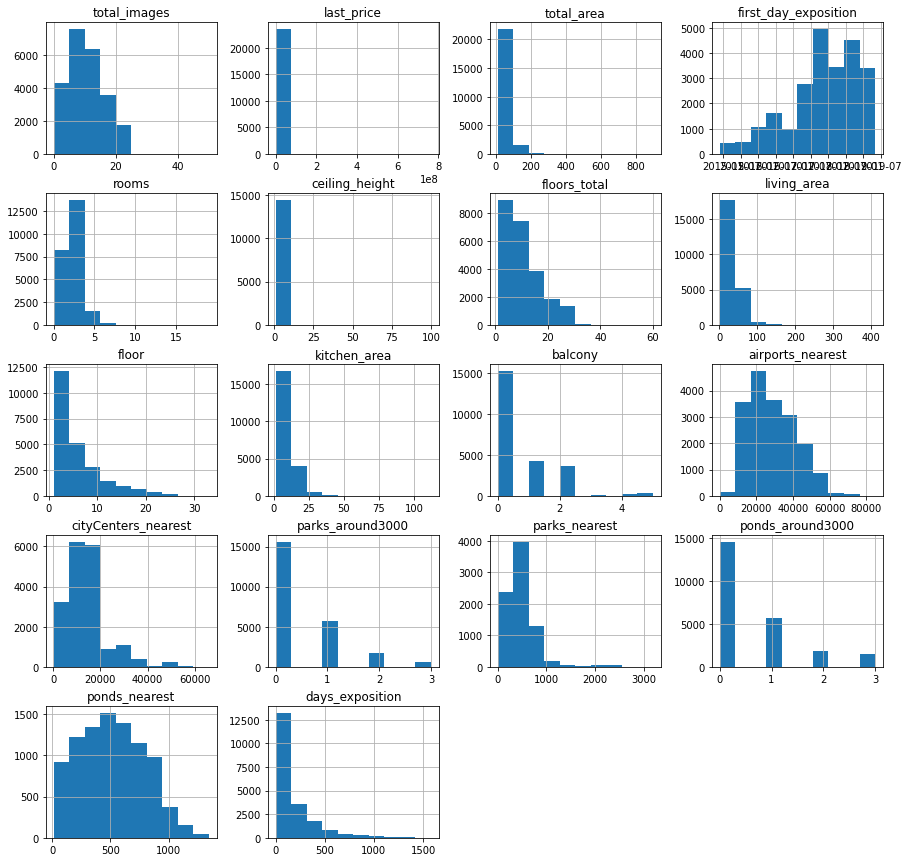

In [24]:
df.hist(figsize=(15, 15))

array([[<AxesSubplot:title={'center':'living_area'}>,
        <AxesSubplot:title={'center':'total_area'}>],
       [<AxesSubplot:title={'center':'kitchen_area'}>,
        <AxesSubplot:title={'center':'rooms'}>],
       [<AxesSubplot:title={'center':'last_price'}>, <AxesSubplot:>]],
      dtype=object)

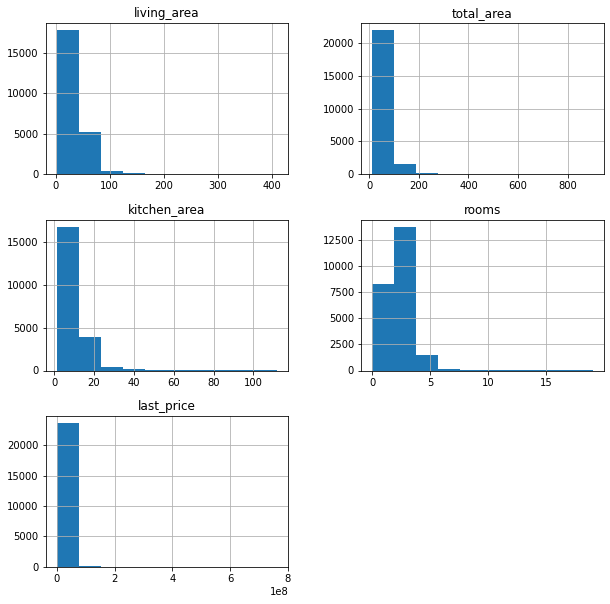

In [25]:
df[['living_area','total_area','kitchen_area','rooms','last_price']].hist(figsize=(10, 10))

*Наблюдение*  
Многовыбросов в данных о площади и в количествах комнат. Удалим их, так как далее будут мешать хорошему анализу.

In [26]:
df1 = df[
    (df['total_area'].gt(10) & df['total_area'].lt(250)) &
    (df['living_area'].gt(5) & df['living_area'].lt(150)) &
    (df['kitchen_area'].lt(45)) &
    (df['last_price'].gt(100000) & df['last_price'].lt(150000000)) &
    (df['rooms'].gt(0) & df['rooms'].lt(8))
].copy()

In [27]:
percentage = (len(df1) / len(df)) * 100
print(percentage)

89.47634921304697


array([[<AxesSubplot:title={'center':'living_area'}>,
        <AxesSubplot:title={'center':'total_area'}>],
       [<AxesSubplot:title={'center':'kitchen_area'}>,
        <AxesSubplot:title={'center':'rooms'}>],
       [<AxesSubplot:title={'center':'last_price'}>, <AxesSubplot:>]],
      dtype=object)

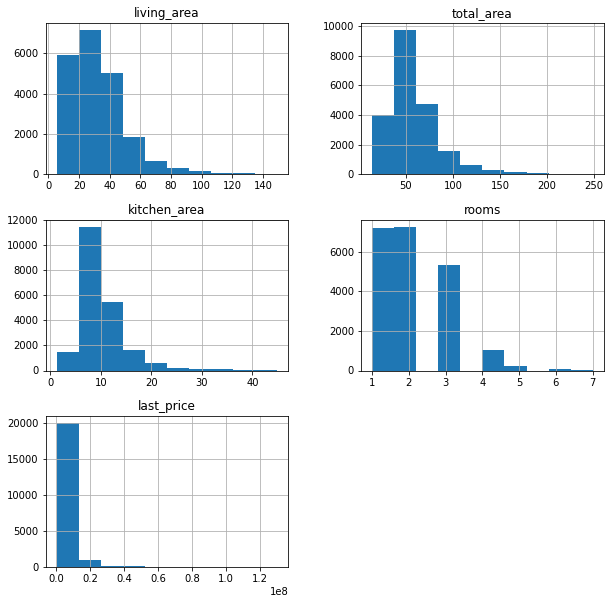

In [28]:
df1[['living_area','total_area','kitchen_area','rooms','last_price']].hist(figsize=(10, 10))

In [29]:
df = df1

*Комментарий*  
Были удалены данные о квартирах больше 250 кв.м., жилой площадью больше 150 кв.м., кухнями больше 45 кв.м. и ценой больше 150 миллионов. Также были удалены около нулевые значения, так как квартиры менее 10 кв.м., жилой площадью меньше 5 кв.м. и дешевле 100000 рублей, точно являются выбросами. Площадь кухни не трогал, потому что бывают квартиры без места под кухню.

**Промежуточный вывод**  
Были удалены пропуски, где это возможно; также изменены типы данных; удалены аномалии и дубликаты. Проведённая обработка может значительно улучшить будущие результаты.

### Посчитайте и добавьте в таблицу новые столбцы

In [30]:
df['price_1square'] = round(df['last_price']/df['total_area'],2)
df['day_week'] = df['first_day_exposition'].dt.dayofweek
df['month'] = df['first_day_exposition'].dt.month
df['year'] = df['first_day_exposition'].dt.year
df['cityCenters_nearest_km'] = round(df['cityCenters_nearest']/1000,0)

df['floors_total'] = df['floors_total'].fillna(0)
def label_floor(row):
    if row['floor'] == row['floors_total']:
        return 'Последний'
    elif row['floor'] == 1:
        return 'Первый'
    else:
        return 'Другой'

df['type_floor'] = df.apply(label_floor, axis=1)

In [31]:
display(df.head(20))

,total_images,last_price,total_area,first_day_exposition,rooms,ceiling_height,floors_total,living_area,floor,is_apartment,...,parks_nearest,ponds_around3000,ponds_nearest,days_exposition,price_1square,day_week,month,year,cityCenters_nearest_km,type_floor
0,20,13000000.0,108.00,2019-03-07,3,2.70,16,51.00,8,False,...,482.0,2,755.0,<NA>,120370.37,3,3,2019,16.0,Другой
1,7,3350000.0,40.40,2018-12-04,1,NaN,11,18.60,1,False,...,NaN,0,NaN,81,82920.79,1,12,2018,19.0,Первый
2,10,5196000.0,56.00,2015-08-20,2,NaN,5,34.30,4,False,...,90.0,2,574.0,558,92785.71,3,8,2015,14.0,Другой
4,2,10000000.0,100.00,2018-06-19,2,3.03,14,32.00,13,False,...,112.0,1,48.0,121,100000.00,1,6,2018,8.0,Другой
5,10,2890000.0,30.40,2018-09-10,1,NaN,12,14.40,5,False,...,NaN,0,NaN,55,95065.79,0,9,2018,NaN,Другой
6,6,3700000.0,37.30,2017-11-02,1,NaN,26,10.60,6,False,...,NaN,0,NaN,155,99195.71,3,11,2017,19.0,Другой
7,5,7915000.0,71.60,2019-04-18,2,NaN,24,30.50,22,False,...,NaN,0,NaN,<NA>,110544.69,3,4,2019,12.0,Другой
8,20,2900000.0,33.16,2018-05-23,1,NaN,27,15.43,26,False,...,NaN,0,NaN,189,87454.76,2,5,2018,NaN,Другой
9,18,5400000.0,61.00,2017-02-26,3,2.50,9,43.60,7,False,...,NaN,0,NaN,289,88524.59,6,2,2017,15.0,Другой
10,5,5050000.0,39.60,2017-11-16,1,2.67,12,20.30,3,False,...,310.0,2,553.0,137,127525.25,3,11,2017,14.0,Другой


**Промежуточный вывод**  
Было добавлено 6 переменных:  
Цена за квадратный метр - общая стоимость делилась на общий метраж;  
Было добавлено три переменных отвечающих за день, месяц, год публикации;  
Переведено растояние до центра из метров в километры;  
И была создана функция отвечающая за создание переменной тип этажа - значения — «первый», «последний», «другой».  
Данные переменные в будущем помогут в исследовании.

### Проведите исследовательский анализ данных

#### Построим гистограммы ко всем параметрам

array([[<AxesSubplot:title={'center':'total_images'}>,
        <AxesSubplot:title={'center':'last_price'}>,
        <AxesSubplot:title={'center':'total_area'}>,
        <AxesSubplot:title={'center':'first_day_exposition'}>,
        <AxesSubplot:title={'center':'rooms'}>],
       [<AxesSubplot:title={'center':'ceiling_height'}>,
        <AxesSubplot:title={'center':'floors_total'}>,
        <AxesSubplot:title={'center':'living_area'}>,
        <AxesSubplot:title={'center':'floor'}>,
        <AxesSubplot:title={'center':'kitchen_area'}>],
       [<AxesSubplot:title={'center':'balcony'}>,
        <AxesSubplot:title={'center':'airports_nearest'}>,
        <AxesSubplot:title={'center':'cityCenters_nearest'}>,
        <AxesSubplot:title={'center':'parks_around3000'}>,
        <AxesSubplot:title={'center':'parks_nearest'}>],
       [<AxesSubplot:title={'center':'ponds_around3000'}>,
        <AxesSubplot:title={'center':'ponds_nearest'}>,
        <AxesSubplot:title={'center':'days_exposition'}

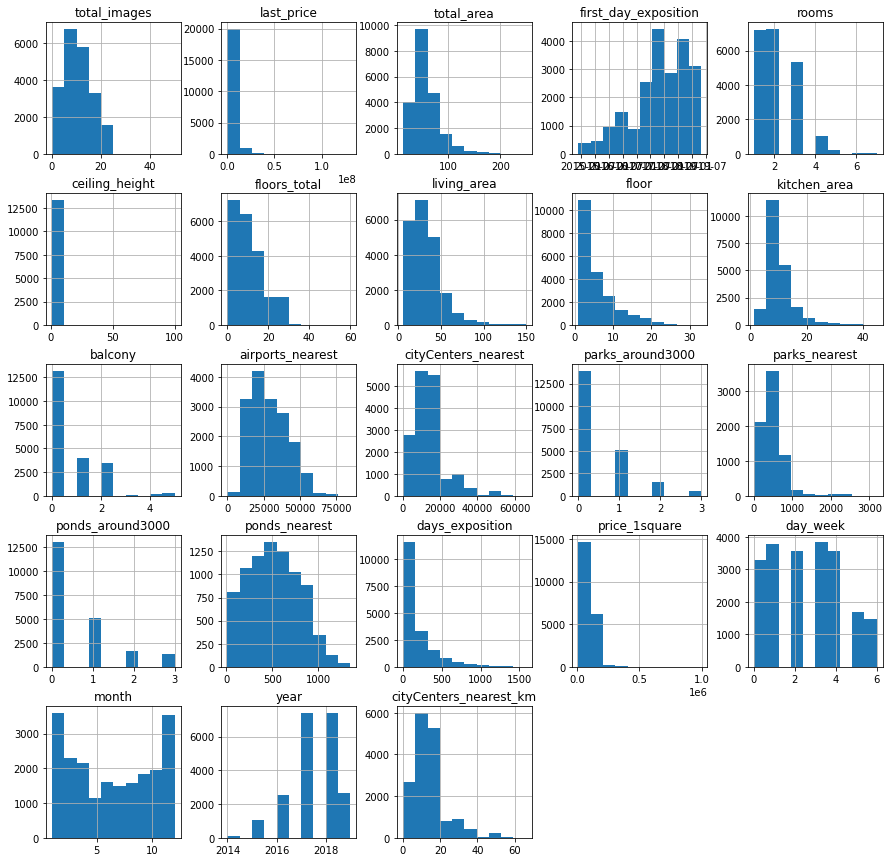

In [32]:
df.hist(figsize=(15, 15))

Рассмотрим гистограмму каждого параметра поближе.

<AxesSubplot:>

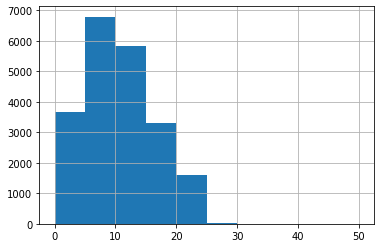

In [33]:
df['total_images'].hist()

*Комментарий*  
Этот параметр нам ничего не даёт в принципе можно оставить как есть.

<AxesSubplot:>

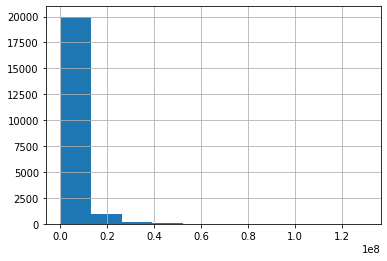

In [34]:
df['last_price'].hist()

*Комментарий*  
Также оставим как есть, потому что мы уже с ним работали и данные отображены логично. Чем больше цена, тем меньше квартир с такой ценой.

<AxesSubplot:>

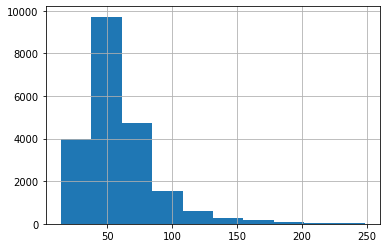

In [35]:
df['total_area'].hist()

*Комментарий*  
Также оставим как есть, потому что мы уже с ним работали и данные отображены логично.

<AxesSubplot:>

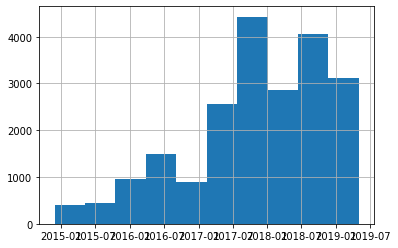

In [36]:
df['first_day_exposition'].hist()

*Комментарий*  
Также оставим как есть, потому что данные отображены логично, чем ближе к 2020 тем больше объявлений, потому что возросла популярность сервиса яндекс недвижимость.

<AxesSubplot:>

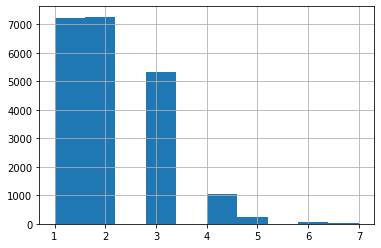

In [37]:
df['rooms'].hist()

*Комментарий*  
Также оставим как есть, потому что мы уже с ним работали и данные отображены логично.

<AxesSubplot:>

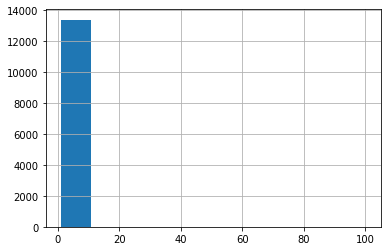

In [38]:
df['ceiling_height'].hist()

<AxesSubplot:>

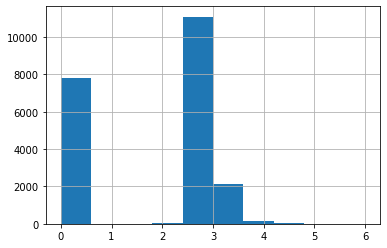

In [39]:
df['ceiling_height'] = df['ceiling_height'].fillna(0)
df['ceiling_height'] = df['ceiling_height'].apply(lambda row: row/10 if row>=15 else row)
df = df[df['ceiling_height'] < 7]
df['ceiling_height'].hist()

<AxesSubplot:>

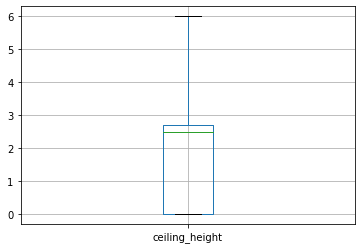

In [40]:
df[['ceiling_height']].boxplot()

*Комментарий*  
Очень большая высота у потолков была и много пропусков, поэтому поэтому пропуски были заменены на нули, удалены значения высотности больше 7 метров, также было предположено, что если высота этажа более 15 метров, скорее всего была осущетвлена ошибка при внесении данных и не поставлена запятая.  

Теперь данные выглядят логично, в среднем высота этажа в районе 2,5 - 3 метра, а все нули это пропуски в данных, это будет учитываться далее.

<AxesSubplot:>

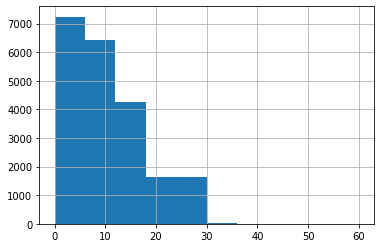

In [41]:
df['floors_total'].hist()

<AxesSubplot:>

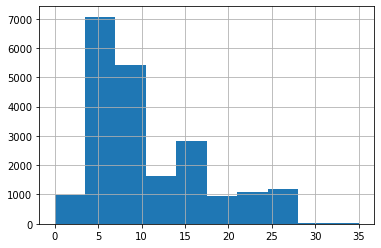

In [42]:
df = df[df['floors_total']<=35]
df['floors_total'].hist()

*Комментарий*  
Для Питера здания более 35 этажей это не типично, по этому их можно удалить.  
Теперь данные выглядят логично, в среднем этажность зданий равняется 5, что типично для Питера.

<AxesSubplot:>

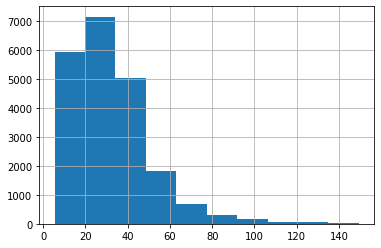

In [43]:
df['living_area'].hist()

*Комментарий*  
Также оставим как есть, потому что мы уже с ним работали и данные отображены логично.

<AxesSubplot:>

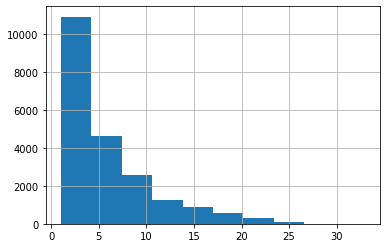

In [44]:
df['floor'].hist()

*Комментарий*  
Также оставим как есть, потому что мы уже с ним работали и данные отображены логично.

<AxesSubplot:>

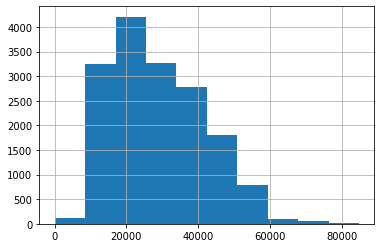

In [45]:
df['airports_nearest'].hist()

*Комментарий*  
Также оставим как есть, потому что данные отображены логично. Пулковский аэропорт находится в черте города, поэтому есть квартиры которые находятся не далеко от него, а есть те которые далеко, которые могут быть на другом берегу Невы за станцией метро беговая.

<AxesSubplot:>

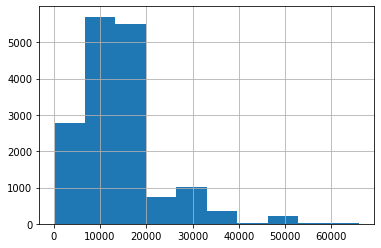

In [46]:
df['cityCenters_nearest'].hist()

*Комментарий*  
Также оставим как есть, потому что данные отображены логично. Эта гистограмма подтверждает, рассуждения по поводу растояния до аэропорта. Есть много зданий находящихся рядом с центром, а также далёкие, которые находятся в курортном, ломоносовских районах города.  
Это происходит потому что город вытянут глубоко в финский залив.

<AxesSubplot:>

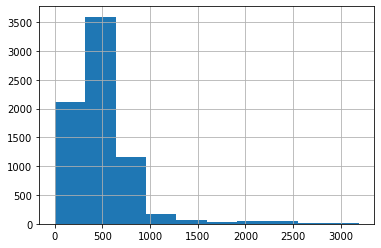

In [47]:
df['parks_nearest'].hist()

*Комментарий*  
Также оставим как есть, потому что данные отображены логично. Неудивительно, что до парков в Питере не большие расстояния, потому что по городу расположено около 70 парков, около 800 скверов и ещё более 500 озеленённых участков территории.

<AxesSubplot:>

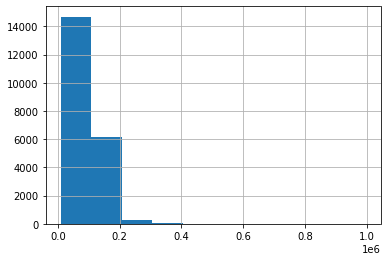

In [48]:
df['price_1square'].hist()

<AxesSubplot:>

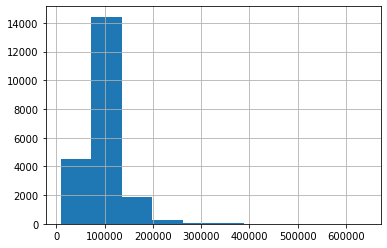

In [49]:
df = df[df['price_1square']<650000]
df['price_1square'].hist()

<AxesSubplot:>

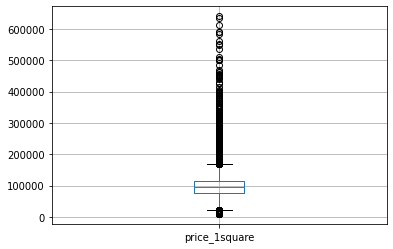

In [50]:
df[['price_1square']].boxplot()

*Комментарий*  
Были удалены квартиры с ценой за квадратный метр более 650 тысяч, потому что такие квартиры на 2025 год в Москве мало найдёшь, если конечно это не супер элитное жильё, а здесь данные до 2020 года.  
А так данные выглядят логично, что чаще всего встречаются цены за квадратный метр в районе 100000 рублей.

array([[<AxesSubplot:title={'center':'day_week'}>]], dtype=object)

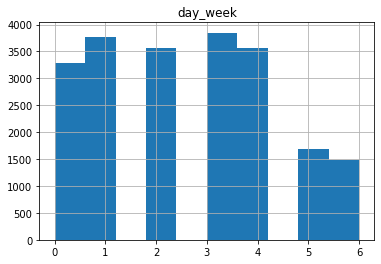

In [51]:
df[['day_week']].hist()

*Комментарий*  
Также оставим как есть, потому что данные отображены логично.  
Чаще всего выкладываются публикации в будни, потому что именно тогда работают агенста недвижимости. В выходные же большую часть скорее всего публикуют собственники квартир.

array([[<AxesSubplot:title={'center':'month'}>]], dtype=object)

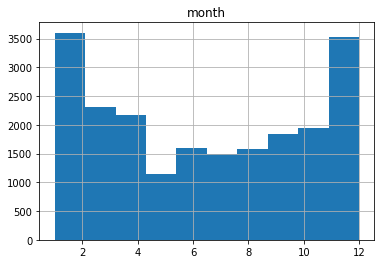

In [52]:
df[['month']].hist()

*Комментарий*  
Также оставим как есть, потому что данные отображены логично.  
Трудно объяснить почему в декабре январе больше всего публикаций, наверное это связано с тем, что обычно объекты к этим датам чаще всего сдают. Меньше всего в мае. Для более точного определения с чем это связано, нужны дополнительные параметры и больше исследований.

In [53]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 21191 entries, 0 to 23698
Data columns (total 28 columns):
 #   Column                  Non-Null Count  Dtype         
---  ------                  --------------  -----         
 0   total_images            21191 non-null  int64         
 1   last_price              21191 non-null  float64       
 2   total_area              21191 non-null  float64       
 3   first_day_exposition    21191 non-null  datetime64[ns]
 4   rooms                   21191 non-null  int64         
 5   ceiling_height          21191 non-null  float64       
 6   floors_total            21191 non-null  Int64         
 7   living_area             21191 non-null  float64       
 8   floor                   21191 non-null  int64         
 9   is_apartment            21191 non-null  boolean       
 10  studio                  21191 non-null  bool          
 11  open_plan               21191 non-null  bool          
 12  kitchen_area            21191 non-null  float6

*Наблюдение*  
Были рассмотрены и объяснены параметры, доделаны упущенные моменты ранее. Распределение данных логично. Большая часть данных осталась в сохранности, удалено в районе 15%. Можно продолжать исследование.

#### Изучите, как быстро продавались квартиры (столбец days_exposition).

<AxesSubplot:>

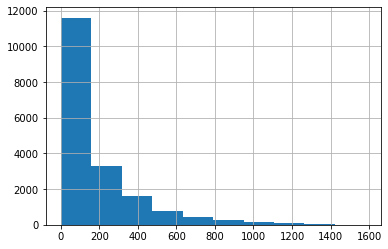

In [54]:
df['days_exposition'].hist()

In [55]:
mean_days = df['days_exposition'].mean()
median_days = df['days_exposition'].median()

print(f"Среднее: {mean_days:.2f}")
print(f"Медиана: {median_days}")

Среднее: 184.54
Медиана: 101.0


*Вывод*  
По данным в среднем за 185 дней квартира продаётся с момента публикации объявления.  
Необычно быстрыми можно считать продажи быстре чем за две недели (14 дней).  
Необычно долгими можно считать продажи позже от 1,5 до 2 лет (от 547 до 730 дней).

#### Какие факторы больше всего влияют на общую (полную) стоимость объекта?

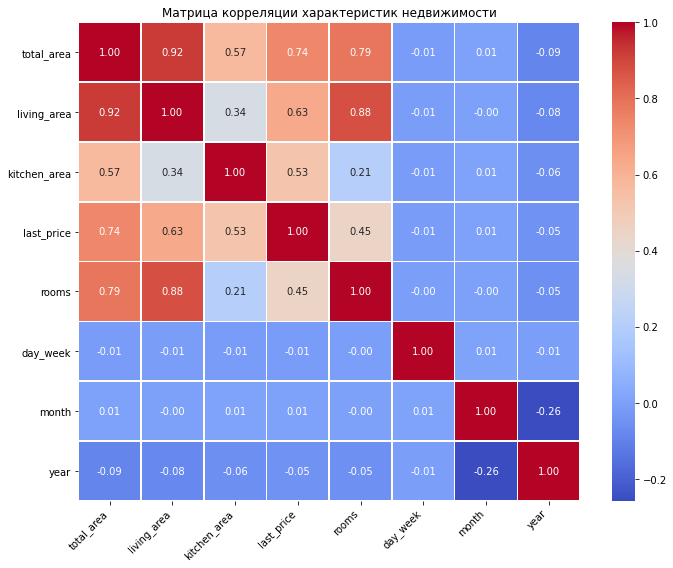

In [56]:
corr_matrix = df[['total_area', 'living_area', 'kitchen_area', 'last_price', 'type_floor', 'rooms', 'day_week', 'month', 'year']].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap="coolwarm", fmt=".2f", linewidths=.5)  
plt.xticks(rotation=45, ha="right")  
plt.yticks(rotation=0)  
plt.title("Матрица корреляции характеристик недвижимости")
plt.tight_layout()  
plt.show()

*Наблюдение*  
Больше всего на цену влияют площадные параметры, что не удивительно. Также влияет количество комнат, что тоже логично. Можно сказать, что практически полностью не влияют параметры связанные с датой.

In [57]:
columns_to_analyze = ['total_area', 'living_area', 'kitchen_area', 'rooms', 'type_floor', 'day_week', 'month', 'year']
aggregated_data = {}
for column in columns_to_analyze:
    aggregated_data[column] = df.groupby(column)['last_price'].mean().reset_index()

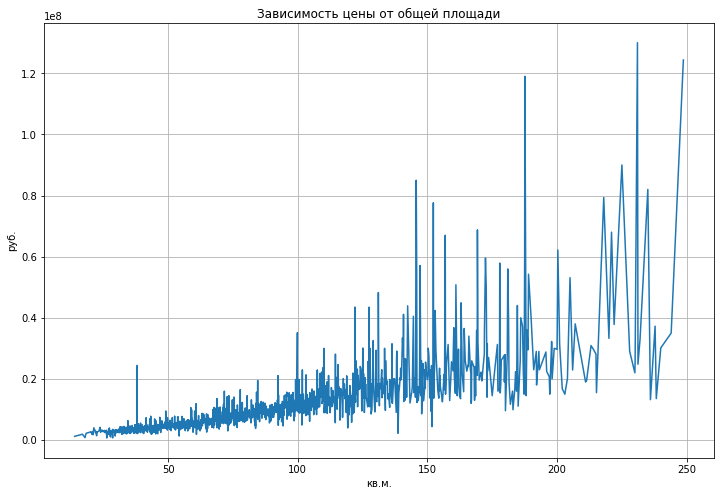

In [58]:
plt.figure(figsize=(12, 8))
sns.lineplot(x='total_area', y='last_price', data=aggregated_data['total_area'])
plt.title('Зависимость цены от общей площади')
plt.xlabel('кв.м.')
plt.ylabel('руб.')
plt.grid()
plt.show()

*Вывод*  
Общая площадь влияет на цену квартиры, чем больше площадь тем выше цена, есть выбросы которые связаны с тем, что присутвуют и другие факторы влияющие на цену.

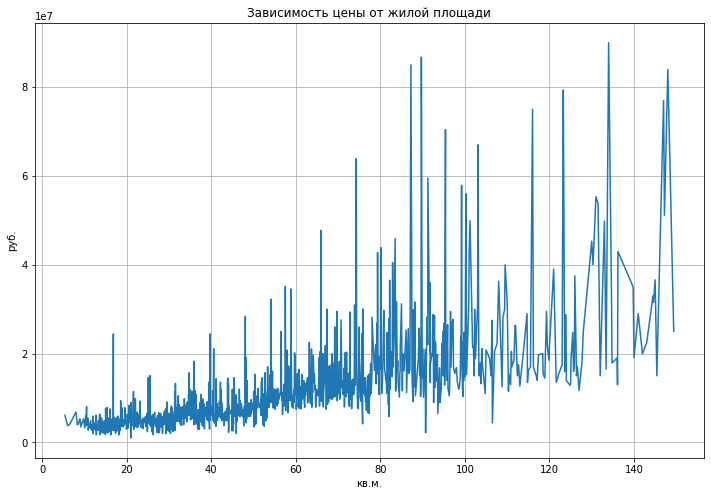

In [59]:
plt.figure(figsize=(12, 8))
sns.lineplot(x='living_area', y='last_price', data=aggregated_data['living_area'])
plt.title('Зависимость цены от жилой площади')
plt.xlabel('кв.м.')
plt.ylabel('руб.')
plt.grid()
plt.show()

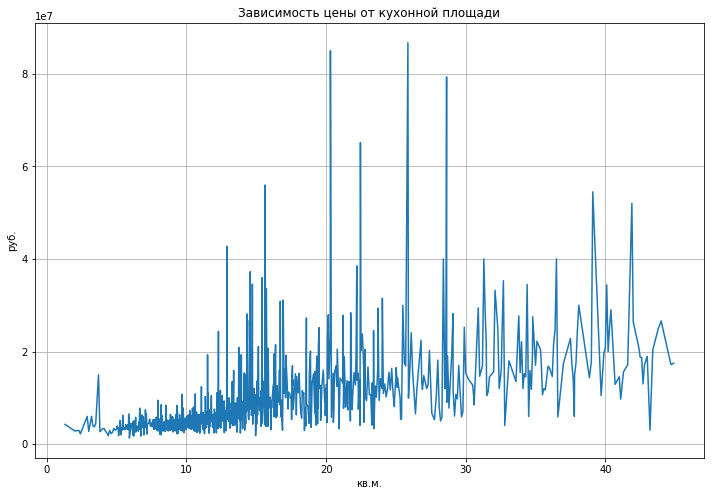

In [60]:
plt.figure(figsize=(12, 8))
sns.lineplot(x='kitchen_area', y='last_price', data=aggregated_data['kitchen_area'])
plt.title('Зависимость цены от кухонной площади')
plt.xlabel('кв.м.')
plt.ylabel('руб.')
plt.grid()
plt.show()

*Вывод*  
Так как общая площадь влияет на цену, можно логически предположить, что жилая площадь и площадь кухни также влияют на цену. Что подтверждают графики, конечно в меньшей степенивыражается влияние, но оно есть. площадь кухни меньше влияет, чем жилая площадь, так как график находится ближе к оси x. Также по графику видно, что после 25 квадратных метров площадь кухни меньше влияет на цену, так как график идёт практически параллельно оси абцисс.

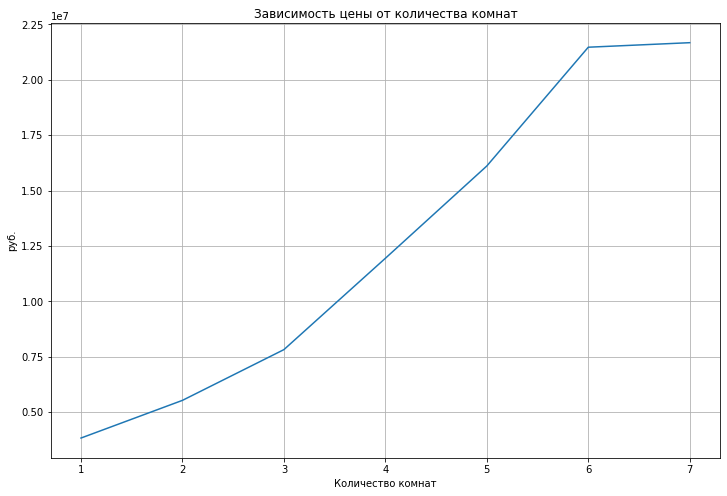

In [61]:
plt.figure(figsize=(12, 8))
sns.lineplot(x='rooms', y='last_price', data=aggregated_data['rooms'])
plt.title('Зависимость цены от количества комнат')
plt.xlabel('Количество комнат')
plt.ylabel('руб.')
plt.grid()
plt.show()

*Вывод*  
Здесь аналогично, что чем больше площадь квартиры тем больше комнат,также можно это увидеть и на матрице корреляции.  
Количество комнат прямо пропорционально влияет на цену. Видно, что тенденция практически нарушается при 7 комнатах, это может быть связано с тем, что квартиры где 7 кумнат, не такие большие по сравнению с 6 комнатными, их просто сильнее раздробили.

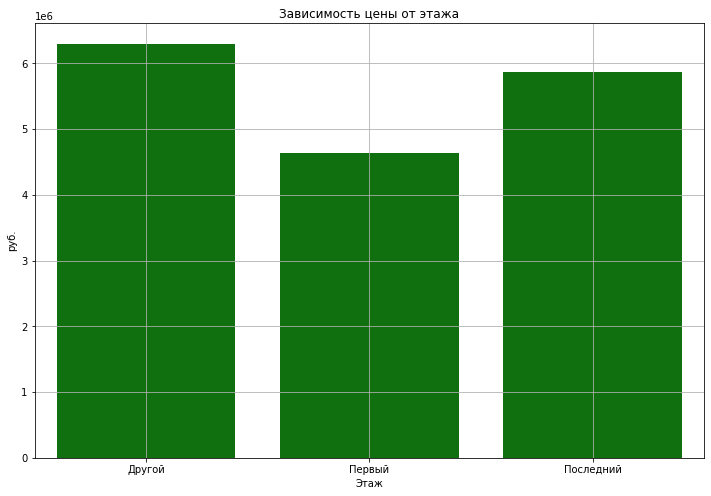

In [62]:
plt.figure(figsize=(12, 8))
sns.barplot(x='type_floor', y='last_price', data=aggregated_data['type_floor'], color = 'green')
plt.title('Зависимость цены от этажа')
plt.xlabel('Этаж')
plt.ylabel('руб.')
plt.grid()
plt.show()

*Вывод*  
Для лучшего визуального отображения категориальных данных будем использовать столбцатую диаграмму.  
По диаграмме видно, что есть небольшая зависимость между ценой и этажом квартиры, которую можно поделить так первый этаж цена меньше, потому что обычно шумнее, грязнее и все остальные этажи. Как видно между последним и другими этажами практически нет разницы.

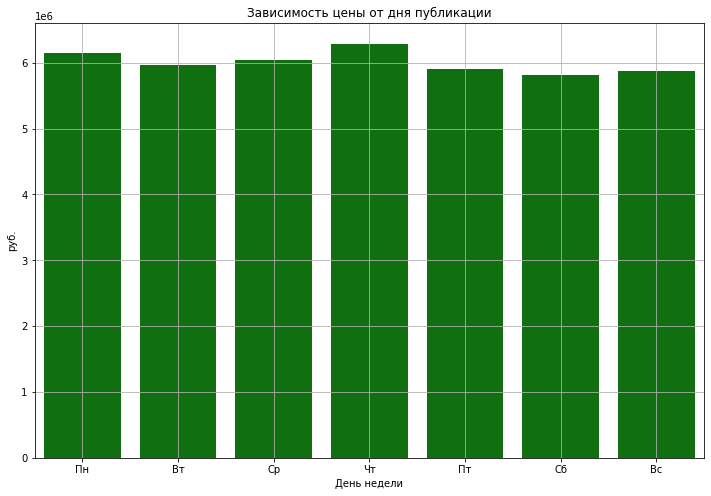

In [63]:
plt.figure(figsize=(12, 8))
sns.barplot(x='day_week', y='last_price', data=aggregated_data['day_week'], color = 'green')
plt.title('Зависимость цены от дня публикации')
plt.xlabel('День недели')
plt.ylabel('руб.')
plt.xticks(ticks=range(7), labels=['Пн', 'Вт', 'Ср', 'Чт', 'Пт', 'Сб', 'Вс'])
plt.grid()
plt.show()

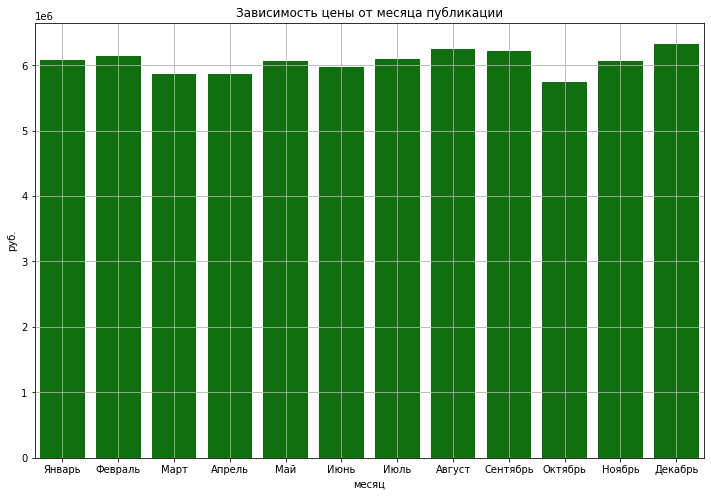

In [64]:
plt.figure(figsize=(12, 8))
sns.barplot(x='month', y='last_price', data=aggregated_data['month'], color = 'green')
plt.title('Зависимость цены от месяца публикации')
plt.xlabel('месяц')
plt.ylabel('руб.')
plt.xticks(ticks=range(12), labels=['Январь', 'Февраль', 'Март', 'Апрель', 'Май', 'Июнь', 'Июль', 'Август', 'Сентябрь', 'Октябрь', 'Ноябрь', 'Декабрь'])
plt.grid()
plt.show()

*Вывод*  
Нет зависимости между днём недели, когда побликация и ценой, что логично. Такая же история и с месяцами.

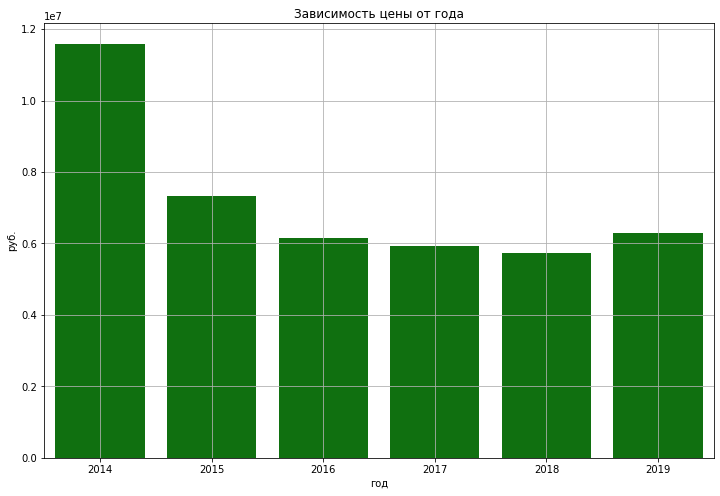

In [65]:
plt.figure(figsize=(12, 8))
sns.barplot(x='year', y='last_price', data=aggregated_data['year'], color = 'green')
plt.title('Зависимость цены от года')
plt.xlabel('год')
plt.ylabel('руб.')
plt.grid()
plt.show()

*Вывод*  
Цена не зависит от года публикации, а 2014 год, можно назвать выбросом, скорее всего связанным с тем, что тогда сервис только начал работать и на него обращали внимание только состоятельные люди. Может есть этому другое объяснение, но для этого нужно больше данных.

#### Посчитайте среднюю цену одного квадратного метра в 10 населённых пунктах с наибольшим числом объявлений. Выделите населённые пункты с самой высокой и низкой стоимостью квадратного метра.

In [66]:
price_column = 'price_1square'
locality_column = 'locality_name'
top_n = 10

summary_price = df.groupby(locality_column).agg(
    количество_объявлений=(price_column, 'count'),
    средняя_цена_за_м2=(price_column, 'mean')
).reset_index()

top_10_kol = summary_price.nlargest(top_n, 'количество_объявлений')
top_10_hprice = summary_price.nlargest(top_n, 'средняя_цена_за_м2')
top_10_lprice = summary_price.nsmallest(top_n, 'средняя_цена_за_м2')

print(f"Топ-{top_n} по количеству объявлений:\n{top_10_kol}\n")
print(f"Топ-{top_n} по самой высокой средней цене за м2:\n{top_10_hprice}\n")
print(f"Топ-{top_n} по самой низкой средней цене за м2:\n{top_10_lprice}")

Топ-10 по количеству объявлений:
       locality_name  количество_объявлений  средняя_цена_за_м2
212  санкт-петербург                  14124       112394.038607
140           мурино                    479        85613.453925
280           шушары                    398        78553.401055
103          кудрово                    389        95320.029820
33        всеволожск                    357        69029.150056
194           пушкин                    333       103034.446486
88           колпино                    321        75129.845452
41           гатчина                    294        68692.933639
164        парголово                    289        90691.341972
34            выборг                    201        58365.453383

Топ-10 по самой высокой средней цене за м2:
       locality_name  количество_объявлений  средняя_цена_за_м2
203           репино                      2       127678.570000
63       зеленогорск                     23       113248.786087
212  санкт-петербург      

*Вывод*  
Больше всего публикаций в Питере(14124), далее идут районы-спутники человейники: Мурино(479), Шушары(398), Кудрово(389). Удивлён, что там так мало публикаций, видимо, тогда муравейников не так много было как сейчас.  
По средней цене за м2 больше всего в Репино(127678.57) и Зеленогорске(113248.78), на третьем месте Санкт-Петербург. Первые два это прибрежные курортные населённые пункты, скорее всего публикации оттуда это элитное жильё. Ну Санкт-Петербруг с высоким ценником, потому что вторая столица страны.  
По средней цене за м2 больше всего в старополье(10368.66), ям-тесово(12328.77), выскатка, потому что это маленькие деревни далеко от Питера и побережья, а также с население от тысячи до полутора тысяч человек.

#### Опишите, как стоимость объектов зависит от расстояния до центра города.

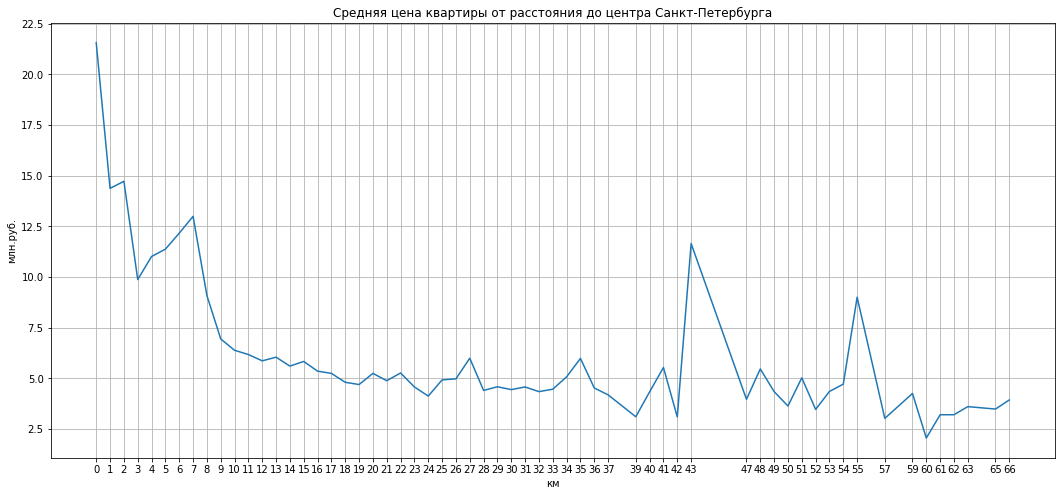

In [67]:
avg_price_km = df.groupby('cityCenters_nearest_km')['last_price'].mean().reset_index()

avg_price_km['last_price_mln'] = round(avg_price_km['last_price'] / 1000000, 2)


plt.figure(figsize=(18, 8))  

plt.plot(avg_price_km['cityCenters_nearest_km'], avg_price_km['last_price_mln']) 
plt.title('Средняя цена квартиры от расстояния до центра Санкт-Петербурга')  
plt.xlabel('км') 
plt.ylabel('млн.руб.') 
plt.xticks(avg_price_km['cityCenters_nearest_km'])  
plt.grid(True) 
plt.show() 

*Вывод*  
Есть зависимость цены от расстояния до центра Санкт-Петребурга. Чем дальше от центра тем меньше цена. Эта зависимость практически невилируется после 39 км, что логично (слишком большим становится расстояние для того, чтоб игралась роль её). Также есть два выброса 43 км и 55 км, что как раз примерно соответвует курортным населённым пунктам Зеленогорску и Репино соответственно, где дорогое жильё.

**Промежуточный вывод**  
Были проанализированны параметры по отдельности. Проверены на адекватность и логичность.  
В ходе исследования были выделены следующие выводы:  
1. Среднее время продажи квартиры после публикации объявления составляет около полугода.
2. Основными факторами, определяющими цену квартиры, являются параметры, связанные с площадью (общая, жилая, кухни) и количеством комнат. Влияние параметров, связанных с датой публикации объявления (день недели, месяц, год), незначительно.
3. Цена квартиры прямо пропорциональна ее общей площади, жилой площади и площади кухни. Влияние площади кухни на цену снижается после определенного порога (около 25 кв.м.). Количество комнат также положительно влияет на цену, хотя встречаются исключения.
4. Цены на первом этаже стоят обычно дешевле.
5. Существует обратная зависимость между ценой квартиры и ее удаленностью от центра Санкт-Петербурга. Эта зависимость нивелируется на расстоянии более 39 км от центра, за исключением отдельных курортных населенных пунктов с дорогим жильем.
6. В данных присутствуют аномалии и выбросы, которые могут быть связаны с особенностями рынка недвижимости в определенные периоды времени (например, 2014 год) или с наличием элитного жилья в определенных населенных пунктах (Репино, Зеленогорск). Также обнаружены населённые пункты в которых очень низкая средняя цена за метр(маленькие деревни).
7. Больше всего объявлений в самом Санкт-Петербурге, далее идут районы с большим количеством ЖК.

### Общий вывод

**Заключение**  
Проведенное исследование рынка недвижимости в Санкт-Петербурге и его окрестностях, включающее предобработку данных (замена типов, удаление пропусков и аномалий) и добавление новых признаков, позволило выявить ключевые факторы, влияющие на цену квартир.  
Определено, что наибольшее влияние оказывают параметры площади (общая, жилая, кухни), количество комнат и удаленность от центра города, в то время как дата публикации объявления и этаж (за исключением первого) оказывают незначительное влияние. Также выявлены аномалии, связанные с элитным жильем (в Зеленогорске и в Репино) и отдельными населенными пунктами. Среднее время продажи квартиры составляет около полугода. Больше всего публикаций с существенным отрывом в Санкт-Петербурге (14124). Самые дешёвые квартиры находятся в маленьких деревушках(в старополье(10368.66 рублей за м2), ям-тесово(12328.77 рублей за м2)) на окраинах мегаполиса.
  
**Кому полезно исследование?**  
Агентства недвижимости - для более точной оценки стоимости объектов недвижимости и разработки эффективных стратегий продаж.  
Покупатели - для понимания факторов, формирующих цену квартиры, и принятия обоснованного решения о покупке.  
Инвесторы - для выявления перспективных районов и объектов для инвестиций в недвижимость.  
Застройщики - для принятия решений о планировании и строительстве новых жилых комплексов, с учетом предпочтений покупателей и ценовых факторов.  
  
**Дальнейшее развитие исследования:**  
1. Рассмотреть факторы, влияющие на цену в зависимости от района города (например, инфраструктура, транспортная доступность, экологическая обстановка).  
2. Учесть макроэкономические показатели (например, инфляция, процентные ставки по ипотеке), которые могут влиять на рынок недвижимости с течением времени.  
3. Разработать модель прогнозирования цен на квартиры на основе выявленных факторов.  
4. Учесть влияние типа дома (панельный, кирпичный, монолитный) и материалов постройки на цену.  
5. Провести более детальный анализ выбросов и аномалий, чтобы выявить причины их возникновения и учесть их при построении моделей.  

Выполнил Лосевский Дмитрий